In [183]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_excel('US Superstore data.xls')
df.head()


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


### Which states have the most sales?

In [184]:
df_gb_sales = df.groupby(['State']).agg(
    tot_sales=('Sales', 'sum')
)

state_max_sales = df_gb_sales['tot_sales'].idxmax()
amount_max_sales = df_gb_sales['tot_sales'].max()

print(f"{state_max_sales} is the state that has the most sales with {amount_max_sales} sales")

California is the state that has the most sales with 457687.6315 sales


### What is the difference between New York and California in terms of sales and profit? (Compare the total sales and profit between New York and California.)

In [185]:
ny_sales = df_gb_sales.loc['New York']['tot_sales']
cal_sales = df_gb_sales.loc['California']['tot_sales']
print(f'New York sales: {ny_sales} / California sales: {cal_sales}')

New York sales: 310876.271 / California sales: 457687.6315


### Who is an outstanding customer in New York?

In [186]:
# df[df['State'] == 'New York']
df_gb_customer = df[df['State'] == 'New York'].groupby(['Customer Name']).agg(
    tot_profits=('Profit', 'sum')
)
max_profit = df_gb_customer.max()['tot_profits']
best_customer = df_gb_customer['tot_profits'].idxmax()

print(f'The best customer is {best_customer} with a profit of {int(max_profit)}')

The best customer is Tom Ashbrook with a profit of 4599


### Are there any differences among states in profitability?

In [187]:
df_gb_profits = df.groupby(['State']).agg(
    tot_profits=('Profit', 'sum')
)
df_gb_profits.sort_values(by='tot_profits', ascending=False)

,tot_profits
State,
California,76381.3871
New York,74038.5486
Washington,33402.6517
Michigan,24463.1876
Virginia,18597.9504
Indiana,18382.9363
Georgia,16250.0433
Kentucky,11199.6966
Minnesota,10823.1874


### The Pareto Principle, also known as the 80/20 rule, is a concept derived from the work of Italian economist Vilfredo Pareto. It states that roughly 80% of the effects come from 20% of the causes. For instance, identifying the top 20% of products that generate 80% of sales or the top 20% of customers that contribute to 80% of profit can help in prioritizing efforts and resources. This focus can lead to improved efficiency and effectiveness in business strategies. Can we apply Pareto principle to customers and Profit ? (Determine if 20% of the customers contribute to 80% of the profit.)

In [188]:

df_gb_sales = df.groupby(['Product Name']).agg(
    tot_sales=('Sales', 'sum')
)
df_gb_sales = df_gb_sales.sort_values(by='tot_sales', ascending=False)
tot_sales = df_gb_sales.sum()['tot_sales']

nb_products = df_gb_sales.count()['tot_sales']
top_20percent = df_gb_sales.head(int(nb_products*.2)).sum()['tot_sales']

print(f'Top 20% products: {int(top_20percent)}, total of sales: {int(tot_sales)}')
print(f'Difference: {round(int(top_20percent)/int(tot_sales), 3)*100} %')

print(f'Almost 80%, we can apply Pareto principle to customers and Profit here.')


Top 20% products: 1765153, total of sales: 2297200
Difference: 76.8 %
Almost 80%, we can apply Pareto principle to customers and Profit here.


### What are the Top 20 cities by Sales ? What about the Top 20 cities by Profit ? Are there any difference among cities in profitability ? (Identify the top 20 cities based on total sales and total profit and analyze differences in profitability among these cities.)

In [189]:
def top20_by(by, col):
    df_gb = df.groupby([by]).agg(
        tot=(col, 'sum')
    )
    df_gb = df_gb.sort_values(by='tot', ascending=False)
    nb = df_gb.count()['tot']

    return df_gb.head(int(nb*.2))

In [190]:
print("Top 20 cities by sales")
df_top20_cities_by_sales =  top20_by('City', 'Sales')
df_top20_cities_by_sales

Top 20 cities by sales


,tot
City,
New York City,256368.1610
Los Angeles,175851.3410
Seattle,119540.7420
San Francisco,112669.0920
Philadelphia,109077.0130
...,...
Parma,3879.7560
Westminster,3826.6460
Bellingham,3790.2400


In [191]:
print("Top 20 cities by profits")
df_top20_cities_by_profits = top20_by('City', 'Profit')
df_top20_cities_by_profits

Top 20 cities by profits


,tot
City,
New York City,62036.9837
Los Angeles,30440.7579
Seattle,29156.0967
San Francisco,17507.3854
Detroit,13181.7908
...,...
Marietta,512.1456
Athens,479.3221
Dubuque,477.6744


### What are the Top 20 customers by Sales?

In [192]:
print("Top 20 customers by sales")
top20_by('Customer Name', 'Sales')

Top 20 customers by sales


,tot
Customer Name,
Sean Miller,25043.050
Tamara Chand,19052.218
Raymond Buch,15117.339
Tom Ashbrook,14595.620
Adrian Barton,14473.571
...,...
Ellis Ballard,4358.128
Gary Zandusky,4355.150
Steven Roelle,4345.886


### Plot the Cumulative curve in Sales by Customers. Can we apply Pareto principle to customers and Sales ?

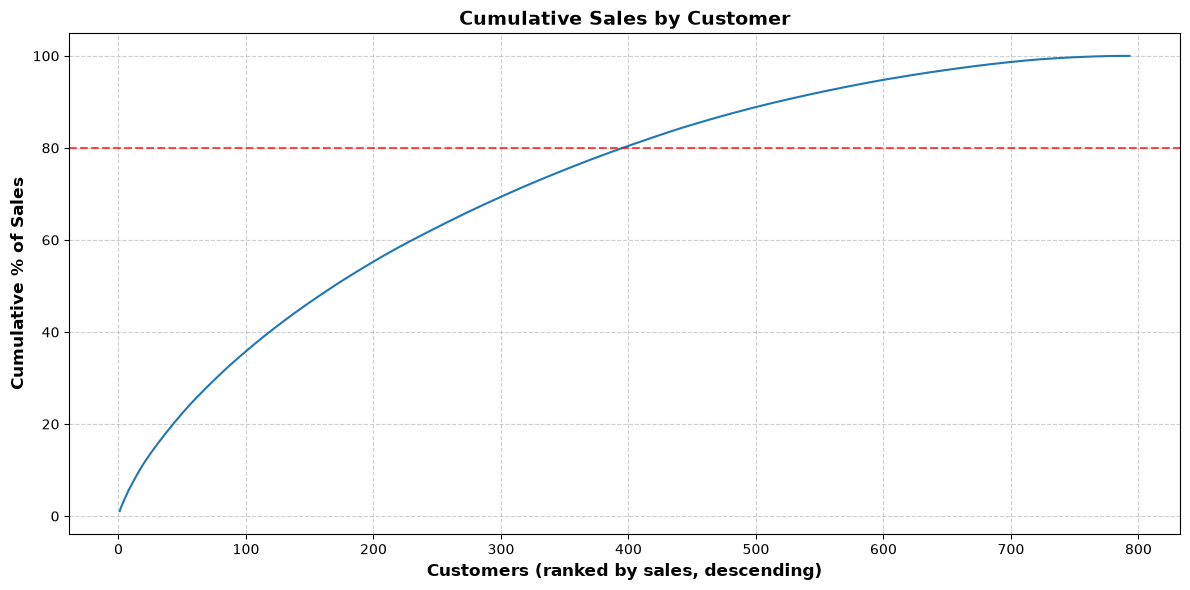

In [193]:
def df_customers_by_sales():
    df_customer_sales = df.groupby('Customer Name').agg(tot_sales=('Sales', 'sum'))
    df_customer_sales = df_customer_sales.sort_values('tot_sales', ascending=False)
    df_customer_sales['cum_sales_pct'] = (
        df_customer_sales['tot_sales'].cumsum() / df_customer_sales['tot_sales'].sum() * 100
    )
    return df_customer_sales

df_customer_sales = df_customers_by_sales()

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(range(1, len(df_customer_sales) + 1), df_customer_sales['cum_sales_pct'], linewidth=1.5)

ax.set_xlabel('Customers (ranked by sales, descending)', fontsize=12, fontweight='bold')
ax.set_ylabel('Cumulative % of Sales', fontsize=12, fontweight='bold')
ax.set_title('Cumulative Sales by Customer', fontsize=14, fontweight='bold')
ax.axhline(80, color='red', linestyle='--', alpha=0.7)
ax.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [194]:
df_customer_sales = df.groupby('Customer Name').agg(tot_sales=('Sales', 'sum'))
df_customer_sales = df_customer_sales.sort_values('tot_sales', ascending=False)

df_customer_sales['cum_sales_pct'] = (
    df_customer_sales['tot_sales'].cumsum() / df_customer_sales['tot_sales'].sum() * 100
)

nb_customers_for_80pct = (df_customer_sales['cum_sales_pct'] >= 80).values.argmax() + 1

total_customers = len(df_customer_sales)
pct_customers_for_80pct = nb_customers_for_80pct / total_customers * 100

print(f"{nb_customers_for_80pct}/{total_customers} "
      f"({pct_customers_for_80pct:.1f}%) generates 80% sales")
if pct_customers_for_80pct > 20:
    print("We can't apply Pareto here")
else:
    print("We can apply Pareto here")

396/793 (49.9%) generates 80% sales
We can't apply Pareto here


### Based on the analysis, make decisions on which states and cities to prioritize for marketing strategies.

In [195]:
df_merged = pd.merge(df_top20_cities_by_sales, df_top20_cities_by_profits, on='City', how='inner').index.tolist()
print(f'The most interesting cities to prioritize for marketing strategies: {", ".join(df_merged)}')

The most interesting cities to prioritize for marketing strategies: New York City, Los Angeles, Seattle, San Francisco, San Diego, Springfield, Detroit, Columbus, Newark, Columbia, Lafayette, Jackson, Arlington, Lakewood, Richmond, Henderson, Atlanta, Minneapolis, Providence, Long Beach, Milwaukee, Franklin, North Las Vegas, Fairfield, Indianapolis, Buffalo, Anaheim, Rochester, Fresno, Yonkers, Lawrence, Florence, Sacramento, Wilmington, Fayetteville, Roswell, Oklahoma City, Decatur, Omaha, Baltimore, San Jose, Chesapeake, Oakland, Virginia Beach, Everett, Tulsa, Clinton, Des Moines, Mobile, Madison, Midland, Brentwood, Morristown, Dover, Lowell, Jamestown, Great Falls, Plainfield, Raleigh, Harrisonburg, Oceanside, Lakeville, Watertown, Cranston, Kenosha, Westminster, Bellingham, Montgomery
